# 0. Config

In [ ]:
# !pip install optuna

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from datasets import load_dataset

import optuna
from optuna.trial import TrialState
import matplotlib.pyplot as plt
import numpy as np
from functools import partial


In [ ]:
# Random Seed 고정 및 Device 설정
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
ds = load_dataset("ethz/food101")

In [ ]:
ds

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 75750
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 25250
    })
})

# 1. Pre-Processing

## 1.1. dataset

In [ ]:
# # Normalize 하기 전 전처리
# stats_transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor()
# ])


# def apply_transform(examples):
#     examples["pixel_values"] = [
#         stats_transform(image.convert("RGB"))
#         for image in examples["image"]
#     ]
#     return examples


# train_dataset = ds["train"]
# train_dataset.set_transform(apply_transform)


# def collate_fn(batch):
#     return torch.stack([item["pixel_values"] for item in batch])


# loader = DataLoader(
#     train_dataset,
#     batch_size=64,
#     shuffle=False,
#     num_workers=4,
#     collate_fn=collate_fn
# )

# # 채널별 합, 제곱합
# channel_sum = torch.zeros(3)
# channel_sum_sq = torch.zeros(3)
# num_pixels = 0

# for images in loader:
#     # images: [B, C, H, W]
#     # print(images.shape)

#     channel_sum += images.sum(dim=[0, 2, 3])
#     # print(channel_sum)
#     channel_sum_sq += (images ** 2).sum(dim=[0, 2, 3])
#     # print(channel_sum_sq)

#     num_pixels += images.size(0) * images.size(2) * images.size(3)

# mean = channel_sum / num_pixels
# std = torch.sqrt(channel_sum_sq / num_pixels - mean ** 2)

# print("Mean:", mean)
# print("Std:", std)

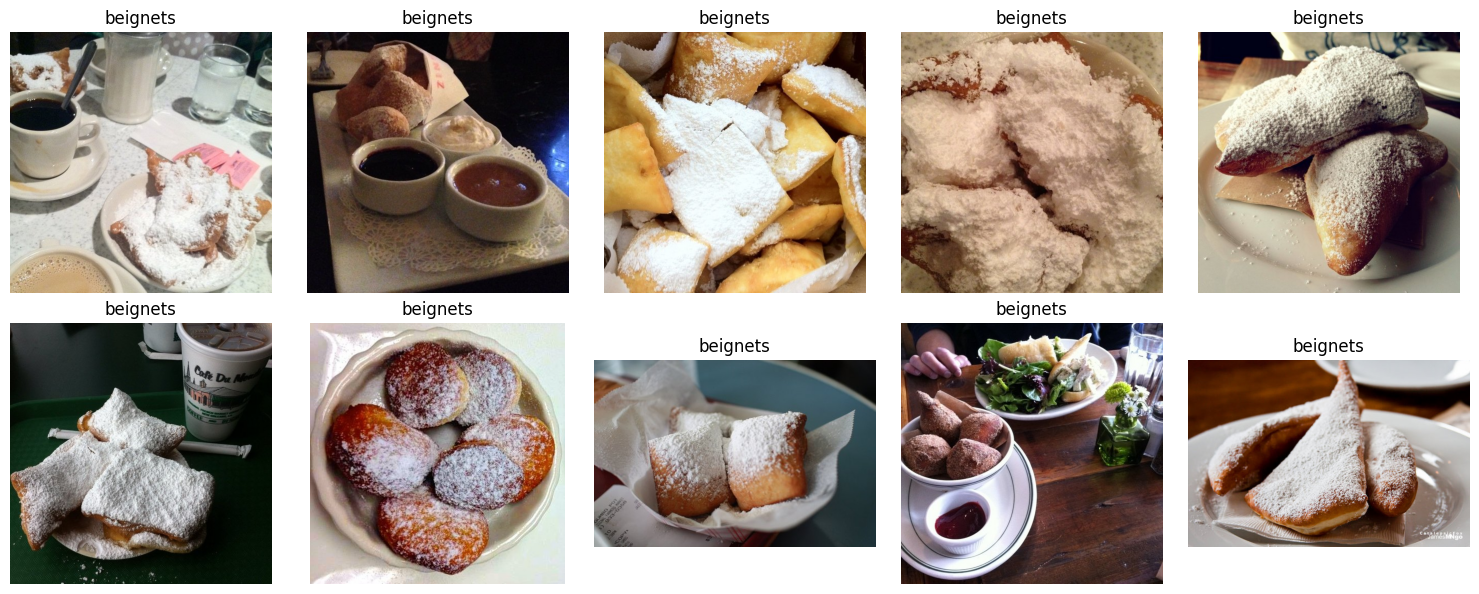

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    sample = ds["validation"][i]

    image = sample["image"]
    label = sample["label"]

    # label 번호 → 음식 이름
    label_name = ds["validation"].features["label"].names[label]

    ax.imshow(image)
    ax.set_title(label_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# 1. 학습용 전처리 (Data Augmentation + Normalization)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)), # Initial resize
    transforms.RandomCrop(224, padding=4, padding_mode='reflect'), # Random crop on 224x224 with padding
    transforms.RandomHorizontalFlip(p=0.5), # 50% 확률로 좌우 반전
    # transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    # transforms.RandomGrayscale(p=0.1),
    # transforms.RandomPerspective(distortion_scale=0.3, p=0.5),
    transforms.ToTensor(), # Convert to Tensor HERE
    # transforms.RandomErasing(p=0.5, scale=(0.02, 0.33), ratio=(0.3, 3.3), value='random'), # Apply RandomErasing AFTER ToTensor
    transforms.Normalize((0.5450, 0.4435, 0.3436), (0.2695, 0.2718, 0.2765)) # Food101 평균/표준편차
])

# 2. 검증/평가용 전처리 (Only Normalization)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5450, 0.4435, 0.3436), (0.2695, 0.2718, 0.2765))
])

In [ ]:
full_train_dataset = ds["train"]

splitted_dataset = full_train_dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = splitted_dataset["train"]
val_dataset = splitted_dataset["test"]


In [ ]:
test_dataset = ds["validation"]

In [ ]:
# Define a helper function to apply the torchvision transforms within the datasets.Dataset.set_transform context
def apply_dataset_transforms(examples, transform):
    # 'examples' is a dictionary containing lists of images and labels from the Hugging Face dataset
    # We apply the provided 'transform' (train_transform or val_transform) to each image
    examples["pixel_values"] = [transform(image.convert("RGB")) for image in examples["image"]]
    examples["labels"] = examples["label"] # Ensure labels are also passed through
    return examples

# Now, use functools.partial to create specific transform functions for each dataset
train_dataset.set_transform(partial(apply_dataset_transforms, transform=train_transform))
val_dataset.set_transform(partial(apply_dataset_transforms, transform=val_transform))
test_dataset.set_transform(partial(apply_dataset_transforms, transform=val_transform))


## 1.2. dataloader

In [ ]:
def collate_fn(batch):
    return {
        "pixel_values": torch.stack([item["pixel_values"] for item in batch]),
        "labels": torch.tensor([item["labels"] for item in batch])
    }

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

Train batches: 474, Val batches: 119, Test batches: 198


# 2. Modeling

## 2.1. custom CNN

In [ ]:
class CustomCNN(nn.Module):
    def __init__(self, conv1_out=32, conv2_out=64, dropout_rate=0.25):
        super(CustomCNN, self).__init__()

        # First Block
        self.block1 = nn.Sequential(
            nn.Conv2d(3, conv1_out, kernel_size=3, padding=1), # 224X224X3 -> 224X224X32
            nn.BatchNorm2d(conv1_out),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 224X224X32 -> 112X112X32
            nn.Dropout(dropout_rate)
        )

        # Second Block
        self.block2 = nn.Sequential(
            nn.Conv2d(conv1_out, conv2_out, kernel_size=3, padding=1), # 112X112X32 -> 112X112X64
            nn.BatchNorm2d(conv2_out),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 112X112X64 -> 56X56X64
            nn.Dropout(dropout_rate)
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        # Fully Connected Layer
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(conv2_out, 101)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.pool(x)
        return self.fc(x)

## 2.2. optuna hyper-parameter tuning

### 2.2.1. objective function

In [ ]:
def objective(trial):
    # 1. 탐색할 하이퍼파라미터 정의 (Search Space)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "RMSprop", "SGD"])
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)
    conv1_out = trial.suggest_categorical("conv1_out", [16, 32])
    conv2_out = trial.suggest_categorical("conv2_out", [32, 64])

    # 2. 모델 및 손실 함수, 옵티마이저 생성
    model = CustomCNN(conv1_out=conv1_out, conv2_out=conv2_out, dropout_rate=dropout_rate).to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == "RMSprop":
        optimizer = optim.RMSprop(model.parameters(), lr=lr)
    else:
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    # 3. 모델 학습 (튜닝 시간 절약을 위해 Trial당 3 Epoch만 진행)
    EPOCHS = 1
    for epoch in range(EPOCHS):
        model.train()
        for batch in train_loader:
            images = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        # 4. 검증 (Validation)
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for batch in val_loader:
                images = batch["pixel_values"].to(device)
                labels = batch["labels"].to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = correct / total

        # Optuna Pruning (가망이 없는 Trial은 조기 종료)
        trial.report(accuracy, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return accuracy

### 2.2.2. training

In [ ]:
# optuna 진행 상황 출력 설정
optuna.logging.set_verbosity(optuna.logging.INFO)

study = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=2, n_warmup_steps=1)
)

# 실습 시간 고려하여 n_trials=10으로 설정 (성능 향상을 원하면 30~50으로 증가)
print("=== 하이퍼파라미터 탐색을 시작합니다 ===")
study.optimize(objective, n_trials=10)

print("\n=== 탐색 완료 ===")
print(f"최고 검증 정확도: {study.best_value:.4f}")
print("최적의 하이퍼파라미터:")
for key, value in study.best_params.items():
    print(f"  - {key}: {value}")

[I 2026-08-28 17:35:45,648] A new study created in memory with name: no-name-b5f8882d-e9f2-4859-b135-a1bd9f4a6d64


=== 하이퍼파라미터 탐색을 시작합니다 ===


/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
[I 2026-08-28 17:55:05,158] Trial 0 finished with value: 0.07452145214521452 and parameters: {'lr': 0.0019330930484628484, 'optimizer': 'RMSprop', 'dropout_rate': 0.2264170992615991, 'conv1_out': 16, 'conv2_out': 32}. Best is trial 0 with value: 0.07452145214521452.



=== 탐색 완료 ===
최고 검증 정확도: 0.0745
최적의 하이퍼파라미터:
  - lr: 0.0019330930484628484
  - optimizer: RMSprop
  - dropout_rate: 0.2264170992615991
  - conv1_out: 16
  - conv2_out: 32


# 3. Evaluation

## 3.1. evaluate(test) best model

In [ ]:
best_params = study.best_params

# 최적 파라미터로 모델 재구성
final_model = CustomCNN(
    conv1_out=best_params['conv1_out'],
    conv2_out=best_params['conv2_out'],
    dropout_rate=best_params['dropout_rate']
).to(device)

criterion = nn.CrossEntropyLoss()

if best_params['optimizer'] == "Adam":
    optimizer = optim.Adam(final_model.parameters(), lr=best_params['lr'])
elif best_params['optimizer'] == "RMSprop":
    optimizer = optim.RMSprop(final_model.parameters(), lr=best_params['lr'])
else:
    optimizer = optim.SGD(final_model.parameters(), lr=best_params['lr'], momentum=0.9)

In [ ]:
# 최종 학습 진행
FINAL_EPOCHS = 10
train_losses, val_accuracies = [], []

print("=== 최종 모델 학습 시작 ===")
for epoch in range(FINAL_EPOCHS):
    final_model.train()
    running_loss = 0.0
    for batch in train_loader:
        images = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)
        optimizer.zero_grad()
        outputs = final_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    # Validation 평가
    final_model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for batch in val_loader:
            images = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)
            outputs = final_model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = correct / total
    val_accuracies.append(val_acc)
    print(f"Epoch [{epoch+1}/{FINAL_EPOCHS}] - Train Loss: {epoch_loss:.4f} | Val Accuracy: {val_acc*100:.2f}%")

=== 최종 모델 학습 시작 ===


Exception in thread Thread-16 (_pin_memory_loop):


KeyboardInterrupt: 

Traceback (most recent call last):
  File "/usr/lib/python3.13/threading.py", line 1044, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "/usr/lib/python3.13/threading.py", line 995, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/_utils/pin_memory.py", line 52, in _pin_memory_loop
    do_one_step()
    ~~~~~~~~~~~^^
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/_utils/pin_memory.py", line 28, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
  File "/usr/lib/python3.13/multiprocessing/queues.py", line 120, in get
    return _ForkingPickler.loads(res)
           ~~~~~~~~~~~~~~~~~~~~~^^^^^
  File "/usr/local/lib/python3.13/dist-packages/torch/multiprocessing/reductions.py", line 540, in rebuild_storage_fd
    fd = df.detach()
  File "/usr/lib/python3.13/multiprocessing/resource_sharer.py", line 57, in detach
    with _resourc

In [ ]:
final_model.eval()
test_correct, test_total = 0, 0
with torch.no_grad():
    for batch in test_loader:
        images = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)
        outputs = final_model(images)
        _, predicted = torch.max(outputs.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

print(f"\n🚀 최종 Test 데이터셋 정확도: {(test_correct/test_total)*100:.2f}%")

## 3.2. visualize test set

In [ ]:
plt.figure(figsize=(12, 5))

# Plot Training Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Validation Accuracy', color='orange')
plt.title('Validation Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()